# Merged Dataset: EDA Notebook
**Notebook 02: EDA on master_dataset.parquet**

Explores the merged master dataset combining Dublin Bikes, Met Éireann weather,
and Irish public holiday calendar. One row = one station at one hour.

**Fixes applied in this version:**
- Temp columns (rain_category, temp_bin, day_type) dropped after each use
- observed=True added to all categorical groupby calls
- is_stockout column dropped after use to keep memory clean

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

MASTER_PATH = r"D:\Griffith College Docs year 2\01 Dissertation\merged-datasets\master_dataset.parquet"

print('Loading master dataset...')
df = pd.read_parquet(MASTER_PATH)
df['datetime_hour'] = pd.to_datetime(df['datetime_hour'])

print(f'Rows            : {len(df):,}')
print(f'Columns         : {len(df.columns)}')
print(f'Unique stations : {df["station_id"].nunique()}')
print(f'Date range      : {df["datetime_hour"].min()} to {df["datetime_hour"].max()}')
print(f'Memory          : {df.memory_usage(deep=True).sum() / 1e9:.2f} GB')
df.head()

Loading master dataset...
Rows            : 7,029,824
Columns         : 28
Unique stations : 117
Date range      : 2019-01-01 00:00:00 to 2026-05-27 15:00:00
Memory          : 1.71 GB


,datetime_hour,station_id,name,lat,lon,capacity,bikes_min,docks_min,bikes_mean,docks_mean,...,hour,month,year,day_of_week,date,is_weekend,is_public_holiday,is_working_day,near_gap,is_imputed
0,2019-01-01,1,CLARENDON ROW,53.340927,-6.262501,31,1,30,1.0,30.0,...,0,1,2019,1,2019-01-01,0,1,0,0,0
1,2019-01-01,2,BLESSINGTON STREET,53.356770,-6.268140,20,1,18,1.1,18.9,...,0,1,2019,1,2019-01-01,0,1,0,0,0
2,2019-01-01,3,BOLTON STREET,53.351181,-6.269859,20,6,13,6.2,13.8,...,0,1,2019,1,2019-01-01,0,1,0,0,0
3,2019-01-01,4,GREEK STREET,53.346874,-6.272976,20,6,14,6.0,14.0,...,0,1,2019,1,2019-01-01,0,1,0,0,0
4,2019-01-01,5,CHARLEMONT PLACE,53.330662,-6.260177,40,27,12,27.2,12.8,...,0,1,2019,1,2019-01-01,0,1,0,0,0


## 1. Dataset Overview

In [2]:
print('=== COLUMN SUMMARY ===')
print(df.dtypes)

print('\n=== MISSING VALUES ===')
missing = df.isnull().sum()
missing = missing[missing > 0]
if len(missing) == 0:
    print('No missing values: all three datasets merged successfully')
else:
    for col, count in missing.items():
        print(f'  {col}: {count:,} ({count/len(df)*100:.2f}%)')

print('\n=== BASIC STATS ===')
print(df[['bikes_min', 'docks_min', 'bikes_mean', 'rain', 'temp', 'rhum']].describe().round(2))

=== COLUMN SUMMARY ===
datetime_hour        datetime64[ns]
station_id                    int16
name                         object
lat                         float32
lon                         float32
capacity                       int8
bikes_min                      int8
docks_min                      int8
bikes_mean                  float64
docks_mean                  float64
reading_count                  int8
rain                        float64
temp                        float64
wetb                        float64
dewpt                       float64
vappr                       float64
rhum                          int16
msl                         float64
hour                           int8
month                          int8
year                          int16
day_of_week                    int8
date                         object
is_weekend                     int8
is_public_holiday             int64
is_working_day                 int8
near_gap                      int64
is_im

## 2. Merge Quality Check

In [3]:
weather_ok    = df['temp'].notna().sum()
weather_miss  = df['temp'].isna().sum()
calendar_ok   = df['is_public_holiday'].notna().sum()
calendar_miss = df['is_public_holiday'].isna().sum()

print('=== MERGE SUCCESS RATES ===')
print(f'Bikes rows total     : {len(df):,} (100%)')
print(f'Weather matched      : {weather_ok:,} ({weather_ok/len(df)*100:.2f}%)')
print(f'Weather not matched  : {weather_miss:,} ({weather_miss/len(df)*100:.2f}%)')
print(f'Calendar matched     : {calendar_ok:,} ({calendar_ok/len(df)*100:.2f}%)')
print(f'Calendar not matched : {calendar_miss:,} ({calendar_miss/len(df)*100:.2f}%)')

print(f'\nNear-gap rows flagged: {df["near_gap"].sum():,}')
print('(Rows near data gaps where lag features would be corrupted)')

gap_rows = df[df['near_gap'] == 1]
if len(gap_rows) > 0:
    print('\nGap periods covered by near_gap flag:')
    gaps = gap_rows.groupby(gap_rows['datetime_hour'].dt.to_period('M')).size()
    for period, count in gaps.items():
        print(f'  {period}: {count:,} rows')

=== MERGE SUCCESS RATES ===
Bikes rows total     : 7,029,824 (100%)
Weather matched      : 7,029,824 (100.00%)
Weather not matched  : 0 (0.00%)
Calendar matched     : 7,029,824 (100.00%)
Calendar not matched : 0 (0.00%)

Near-gap rows flagged: 0
(Rows near data gaps where lag features would be corrupted)


## 3. Stock-Out and Fullness Class Distribution

=== EVENT RATES ===
Total hourly station observations : 7,029,824
Stock-out events (bikes_min = 0)  : 969,217 (13.79%)
Fullness events  (docks_min = 0)  : 359,492 (5.11%)

Class imbalance present: SMOTE will be applied during modelling


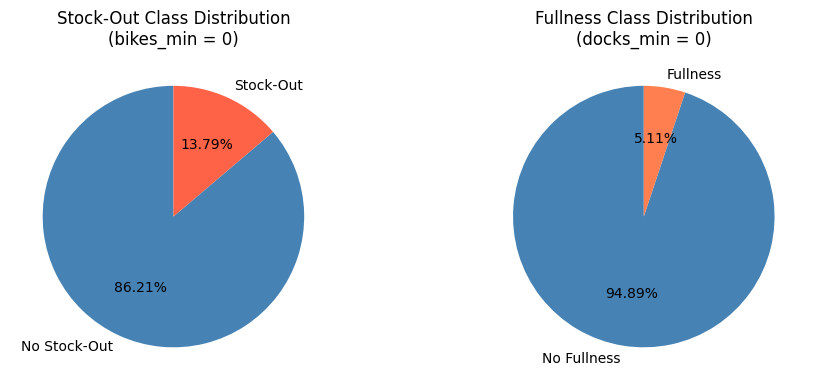

In [4]:
total    = len(df)
stockout = (df['bikes_min'] == 0).sum()
fullness = (df['docks_min'] == 0).sum()

print('=== EVENT RATES ===')
print(f'Total hourly station observations : {total:,}')
print(f'Stock-out events (bikes_min = 0)  : {stockout:,} ({stockout/total*100:.2f}%)')
print(f'Fullness events  (docks_min = 0)  : {fullness:,} ({fullness/total*100:.2f}%)')
print('\nClass imbalance present: SMOTE will be applied during modelling')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].pie([total - stockout, stockout],
            labels=['No Stock-Out', 'Stock-Out'],
            colors=['steelblue', 'tomato'],
            autopct='%1.2f%%', startangle=90)
axes[0].set_title('Stock-Out Class Distribution\n(bikes_min = 0)')

axes[1].pie([total - fullness, fullness],
            labels=['No Fullness', 'Fullness'],
            colors=['steelblue', 'coral'],
            autopct='%1.2f%%', startangle=90)
axes[1].set_title('Fullness Class Distribution\n(docks_min = 0)')

plt.tight_layout()
plt.show()

## 4. Hourly Demand Pattern

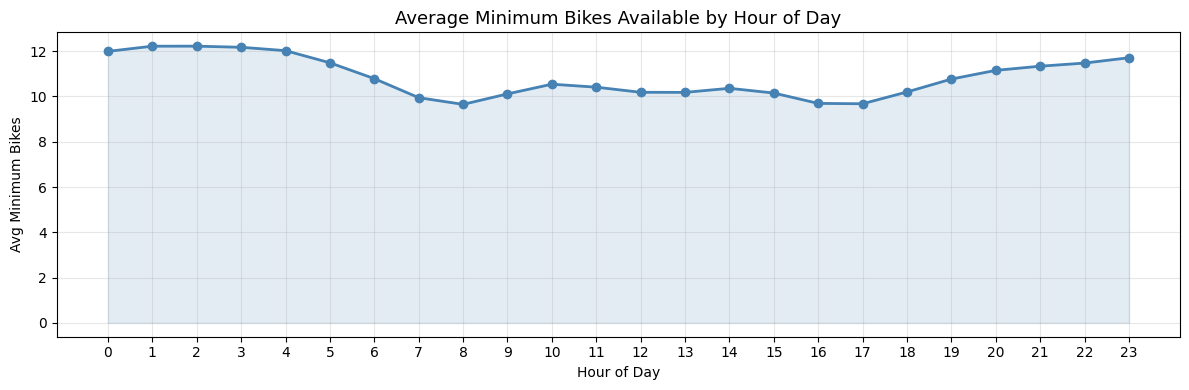

In [5]:
hourly = df.groupby('hour')['bikes_min'].mean()

plt.figure(figsize=(12, 4))
plt.plot(hourly.index, hourly.values, marker='o', color='steelblue', linewidth=2)
plt.fill_between(hourly.index, hourly.values, alpha=0.15, color='steelblue')
plt.title('Average Minimum Bikes Available by Hour of Day', fontsize=13)
plt.xlabel('Hour of Day')
plt.ylabel('Avg Minimum Bikes')
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Weather Features Distributions

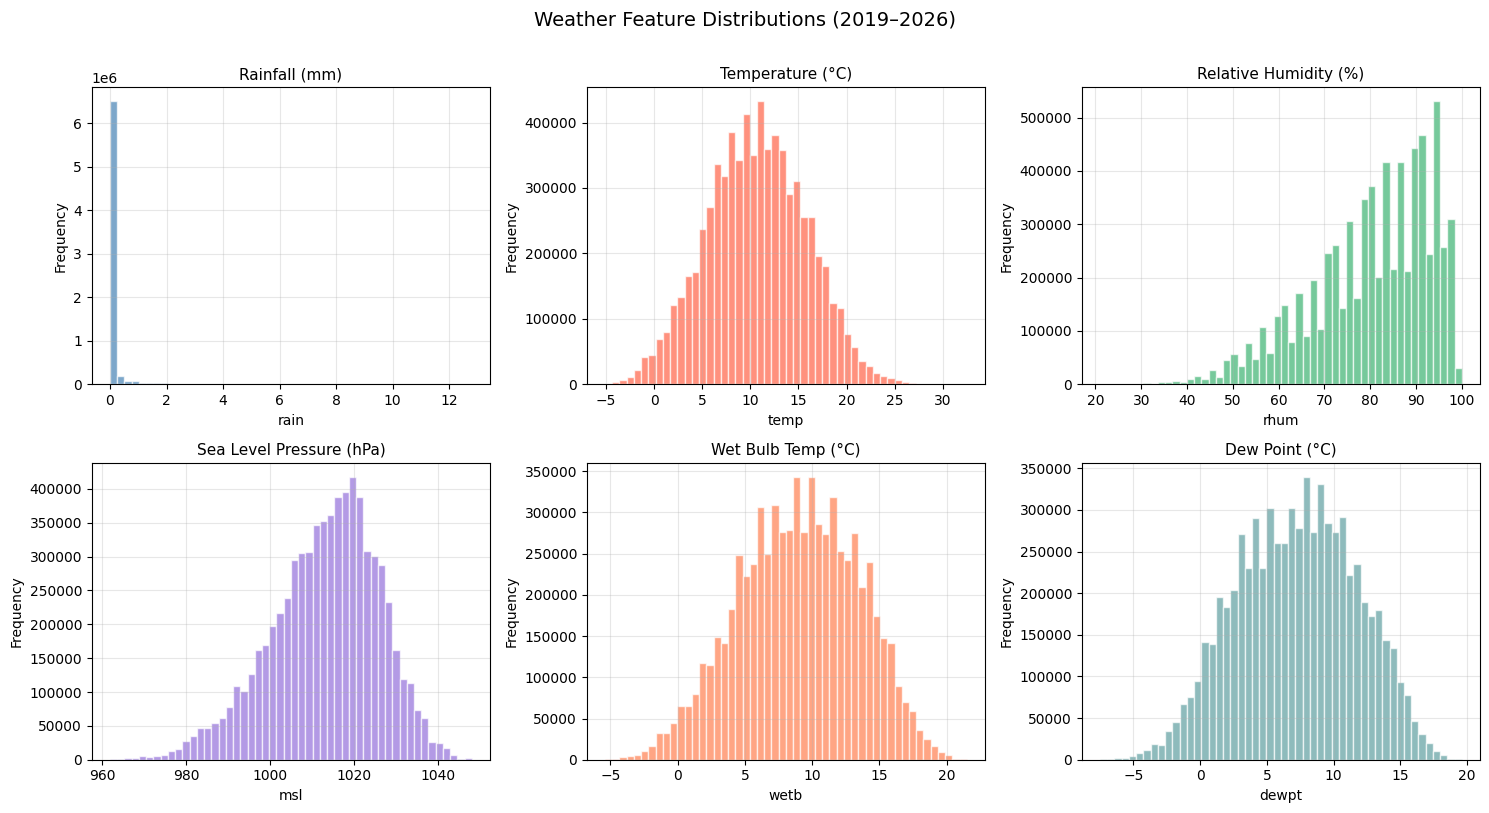

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
weather_cols = ['rain', 'temp', 'rhum', 'msl', 'wetb', 'dewpt']
titles = ['Rainfall (mm)', 'Temperature (°C)', 'Relative Humidity (%)',
          'Sea Level Pressure (hPa)', 'Wet Bulb Temp (°C)', 'Dew Point (°C)']
colors = ['steelblue', 'tomato', 'mediumseagreen',
          'mediumpurple', 'coral', 'cadetblue']

for ax, col, title, color in zip(axes.flatten(), weather_cols, titles, colors):
    ax.hist(df[col].dropna(), bins=50, color=color, alpha=0.7, edgecolor='white')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    ax.grid(True, alpha=0.3)

plt.suptitle('Weather Feature Distributions (2019–2026)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 6. Does Rain Affect Bike Availability?

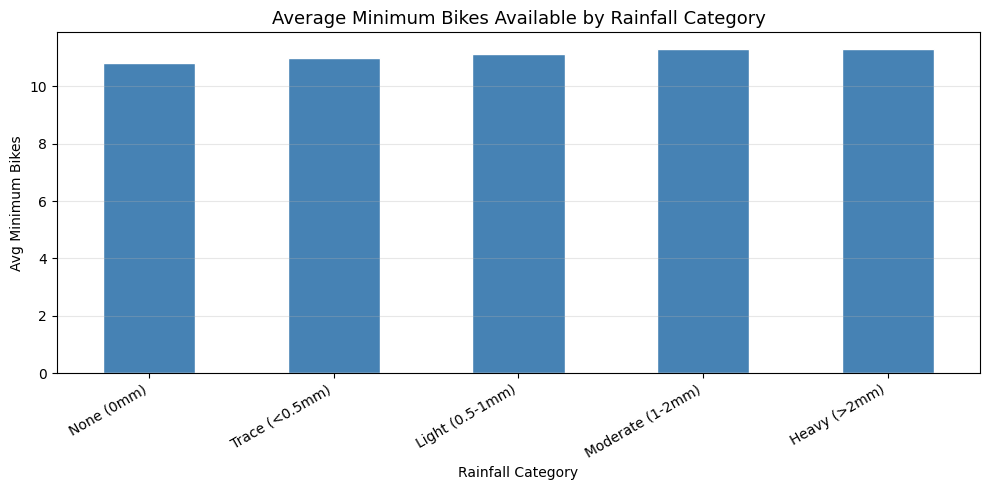

Average bikes by rainfall:
rain_category
None (0mm)          10.82
Trace (<0.5mm)      10.99
Light (0.5-1mm)     11.11
Moderate (1-2mm)    11.31
Heavy (>2mm)        11.30
Name: bikes_min, dtype: float64


In [7]:
df['rain_category'] = pd.cut(
    df['rain'],
    bins=[-0.1, 0, 0.5, 1.0, 2.0, 100],
    labels=['None (0mm)', 'Trace (<0.5mm)',
            'Light (0.5-1mm)', 'Moderate (1-2mm)', 'Heavy (>2mm)']
)

rain_bikes = df.groupby('rain_category', observed=True)['bikes_min'].mean()

plt.figure(figsize=(10, 5))
rain_bikes.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Average Minimum Bikes Available by Rainfall Category', fontsize=13)
plt.xlabel('Rainfall Category')
plt.ylabel('Avg Minimum Bikes')
plt.xticks(rotation=30, ha='right')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print('Average bikes by rainfall:')
print(rain_bikes.round(2))

# Drop temp column immediately after use
df.drop(columns=['rain_category'], inplace=True)

## 7. Temperature vs Stock-Out Risk

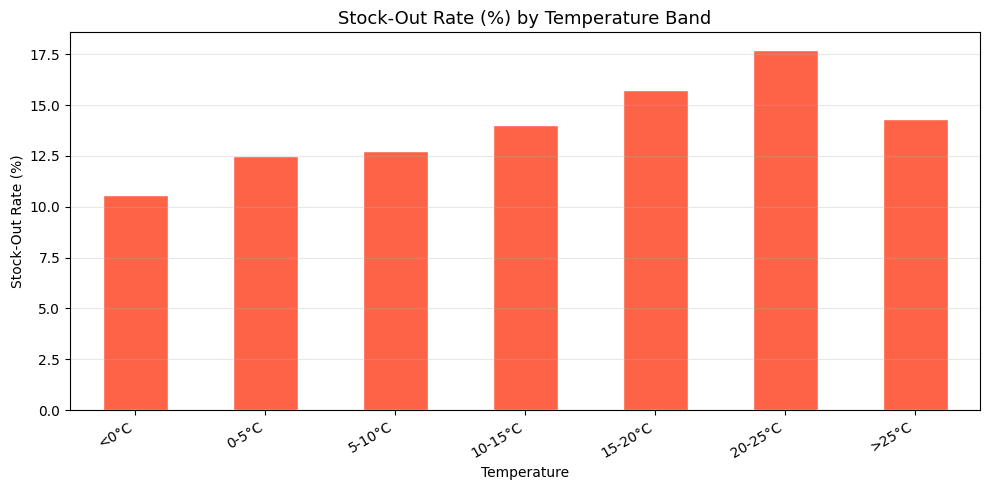

Stock-out rate by temperature:
temp_bin
<0°C       10.59
0-5°C      12.50
5-10°C     12.76
10-15°C    14.04
15-20°C    15.73
20-25°C    17.69
>25°C      14.32
Name: is_stockout, dtype: float64


In [8]:
df['temp_bin'] = pd.cut(
    df['temp'],
    bins=[-10, 0, 5, 10, 15, 20, 25, 40],
    labels=['<0°C', '0-5°C', '5-10°C', '10-15°C', '15-20°C', '20-25°C', '>25°C']
)

df['is_stockout'] = (df['bikes_min'] == 0).astype('int8')
temp_stockout = df.groupby('temp_bin', observed=True)['is_stockout'].mean() * 100

plt.figure(figsize=(10, 5))
temp_stockout.plot(kind='bar', color='tomato', edgecolor='white')
plt.title('Stock-Out Rate (%) by Temperature Band', fontsize=13)
plt.xlabel('Temperature')
plt.ylabel('Stock-Out Rate (%)')
plt.xticks(rotation=30, ha='right')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print('Stock-out rate by temperature:')
print(temp_stockout.round(2))


df.drop(columns=['temp_bin'], inplace=True)

## 8. Working Days vs Weekends vs Public Holidays

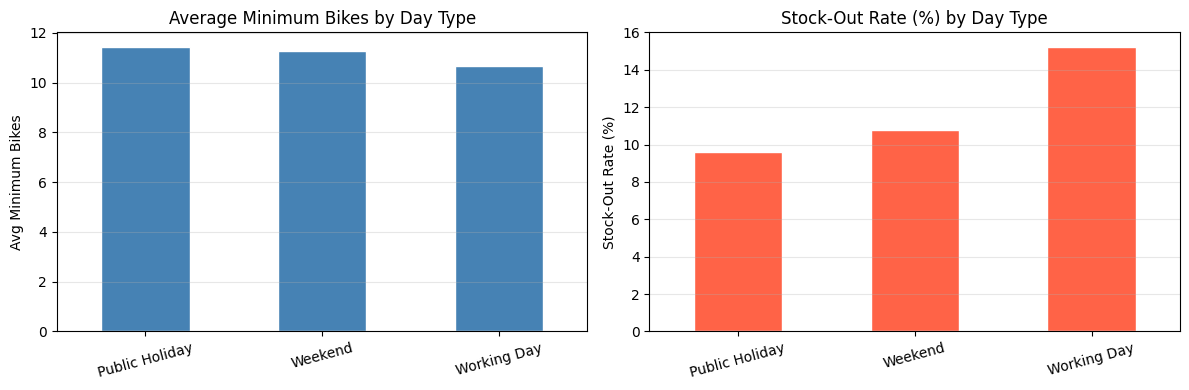

                avg_bikes  stockout_rate
day_type                                
Public Holiday      11.45           9.58
Weekend             11.26          10.79
Working Day         10.65          15.24


In [9]:
# is_stockout already created in cell 7
df['day_type'] = 'Working Day'
df.loc[df['is_weekend'] == 1, 'day_type'] = 'Weekend'
df.loc[df['is_public_holiday'] == 1, 'day_type'] = 'Public Holiday'

day_type_stats = df.groupby('day_type').agg(
    avg_bikes=('bikes_min', 'mean'),
    stockout_rate=('is_stockout', 'mean')
)
day_type_stats['stockout_rate'] = (day_type_stats['stockout_rate'] * 100).round(2)
day_type_stats['avg_bikes'] = day_type_stats['avg_bikes'].round(2)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

day_type_stats['avg_bikes'].plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Average Minimum Bikes by Day Type', fontsize=12)
axes[0].set_ylabel('Avg Minimum Bikes')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=15)
axes[0].grid(True, alpha=0.3, axis='y')

day_type_stats['stockout_rate'].plot(
    kind='bar', ax=axes[1], color='tomato', edgecolor='white')
axes[1].set_title('Stock-Out Rate (%) by Day Type', fontsize=12)
axes[1].set_ylabel('Stock-Out Rate (%)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=15)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()
print(day_type_stats)

# Drop temp column immediately after use
df.drop(columns=['day_type'], inplace=True)

## 9. Heatmap: Stock-Out Rate by Day and Hour

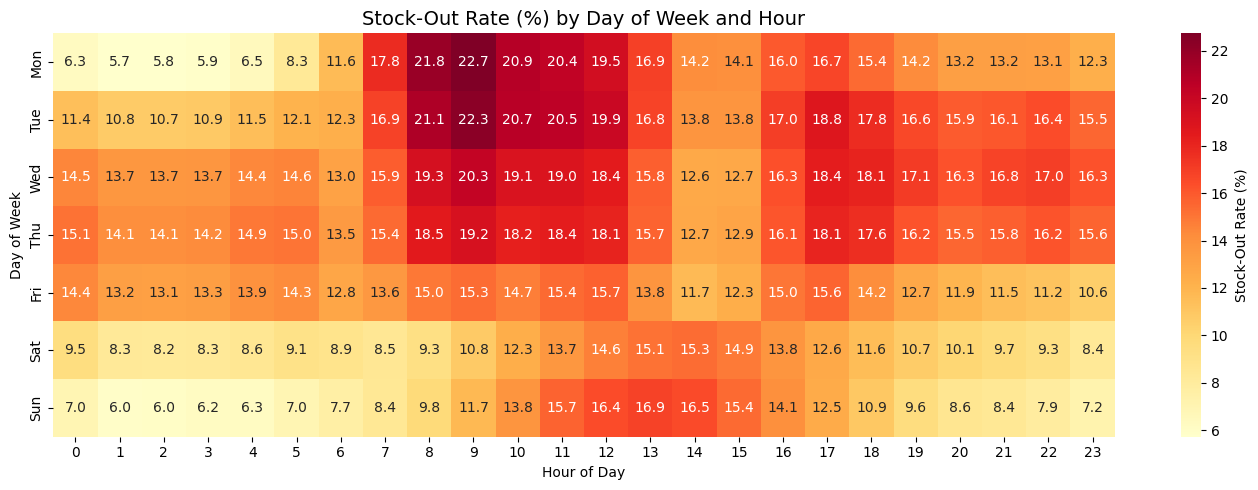


Highest stock-out risk periods:
  Mon at 09:00 = 22.7% stock-out rate
  Tue at 09:00 = 22.3% stock-out rate
  Mon at 08:00 = 21.8% stock-out rate
  Tue at 08:00 = 21.1% stock-out rate
  Mon at 10:00 = 20.9% stock-out rate


In [10]:
# is_stockout already created in cell 7
pivot = df.groupby(['day_of_week', 'hour'])['is_stockout'].mean().unstack() * 100
pivot.index = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

plt.figure(figsize=(14, 5))
sns.heatmap(pivot, cmap='YlOrRd', annot=True, fmt='.1f',
            cbar_kws={'label': 'Stock-Out Rate (%)'})
plt.title('Stock-Out Rate (%) by Day of Week and Hour', fontsize=14)
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.tight_layout()
plt.show()

print('\nHighest stock-out risk periods:')
flat = pivot.stack().sort_values(ascending=False).head(5)
for (day, hour), rate in flat.items():
    print(f'  {day} at {hour:02d}:00 = {rate:.1f}% stock-out rate')

## 10. Feature Correlation with Stock-Out

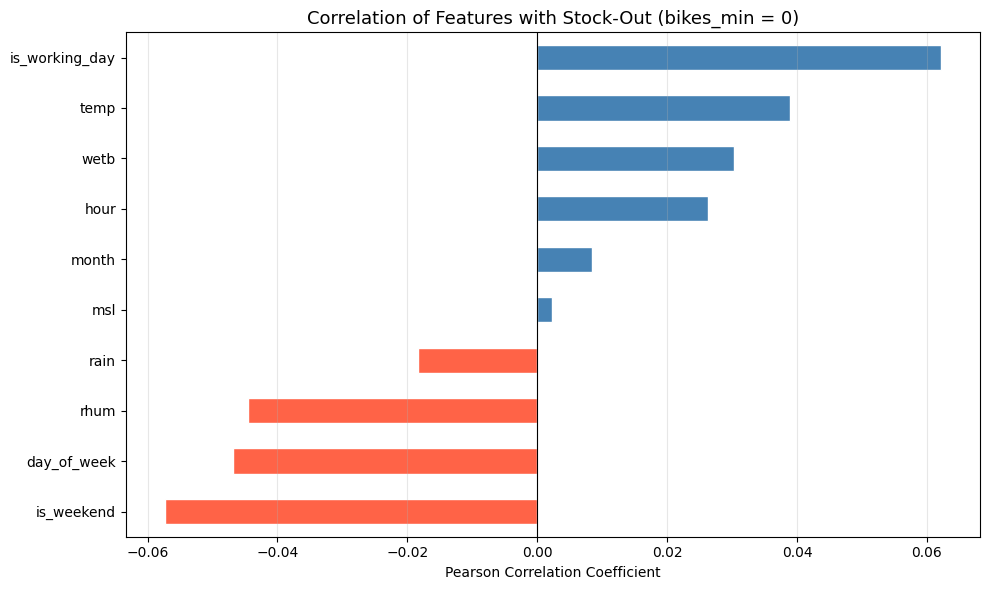

Feature correlations with stock-out:
is_weekend       -0.0574
day_of_week      -0.0469
rhum             -0.0446
rain             -0.0183
msl               0.0023
month             0.0084
hour              0.0263
wetb              0.0303
temp              0.0388
is_working_day    0.0622
Name: is_stockout, dtype: float64

is_stockout column dropped to free memory


In [11]:
# is_stockout already created in cell 7
feature_cols = ['rain', 'temp', 'rhum', 'msl', 'wetb',
                'hour', 'day_of_week', 'month', 'is_working_day', 'is_weekend']

corr = df[feature_cols + ['is_stockout']].corr()['is_stockout'].drop('is_stockout')
corr = corr.sort_values()
colors = ['tomato' if x < 0 else 'steelblue' for x in corr.values]

plt.figure(figsize=(10, 6))
corr.plot(kind='barh', color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Correlation of Features with Stock-Out (bikes_min = 0)', fontsize=13)
plt.xlabel('Pearson Correlation Coefficient')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print('Feature correlations with stock-out:')
print(corr.round(4))

# Drop is_stockout after all cells that use it are done
df.drop(columns=['is_stockout'], inplace=True)
print('\nis_stockout column dropped to free memory')

## 11. Monthly Stock-Out Trend Over Time

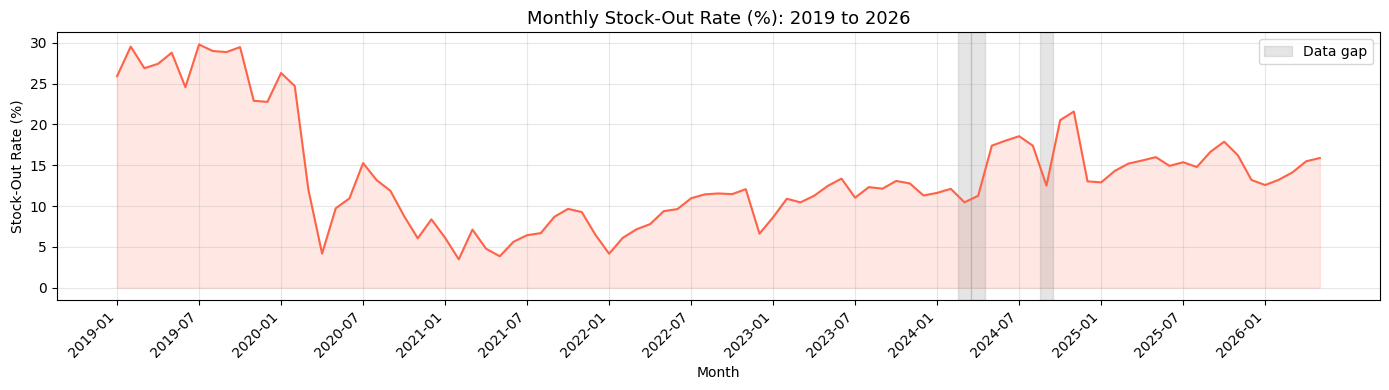

In [12]:
df['is_stockout_tmp'] = (df['bikes_min'] == 0).astype('int8')

monthly = df.groupby(
    df['datetime_hour'].dt.to_period('M')
)['is_stockout_tmp'].mean() * 100

plt.figure(figsize=(14, 4))
months = list(monthly.index.astype(str))
plt.plot(range(len(monthly)), monthly.values, color='tomato', linewidth=1.5)
plt.fill_between(range(len(monthly)), monthly.values, alpha=0.15, color='tomato')

# Shade the data gaps
gap_periods = ['2024-03', '2024-04', '2024-09']
for gp in gap_periods:
    if gp in months:
        idx = months.index(gp)
        plt.axvspan(idx - 0.5, idx + 0.5, alpha=0.2,
                    color='grey', label='Data gap' if gp == gap_periods[0] else '')

plt.title('Monthly Stock-Out Rate (%): 2019 to 2026', fontsize=13)
plt.xlabel('Month')
plt.ylabel('Stock-Out Rate (%)')
tick_positions = range(0, len(monthly), 6)
plt.xticks(tick_positions, [months[i] for i in tick_positions],
           rotation=45, ha='right')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

df.drop(columns=['is_stockout_tmp'], inplace=True)

## 12. Interactive Map: Stock-Out Rate by Station

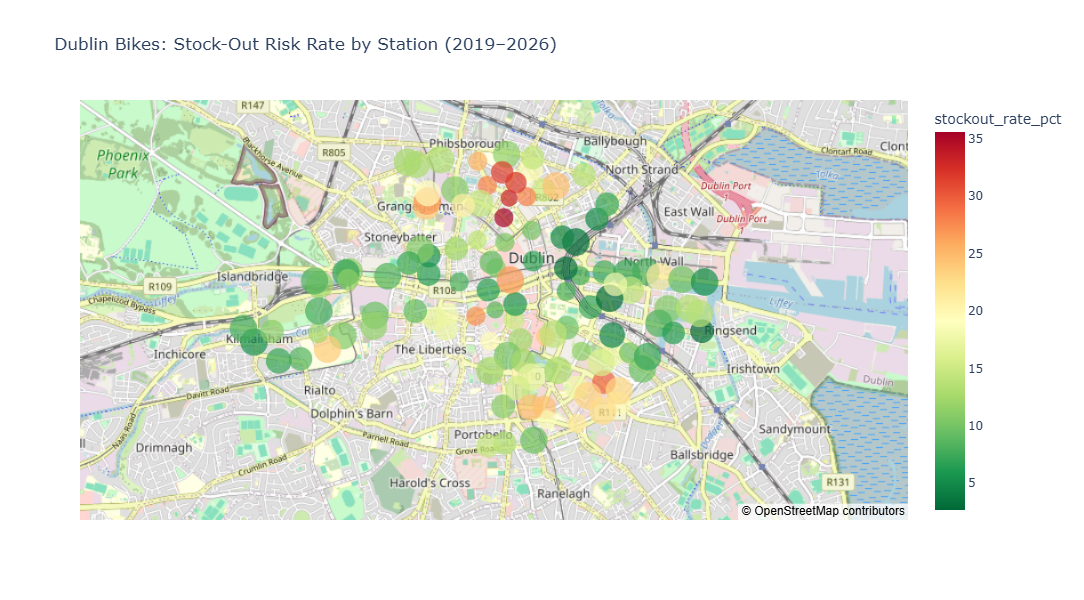


Top 10 highest stock-out risk stations:
                        name  stockout_rate_pct  capacity
        PARNELL SQUARE NORTH              35.61        20
            HARDWICKE STREET              33.19        16
             HARDWICKE PLACE              31.93        25
          ECCLES STREET EAST              31.70        27
           JAMES STREET EAST              29.74        30
        DENMARK STREET GREAT              28.09        20
          BLESSINGTON STREET              28.02        20
          CHRISTCHURCH PLACE              27.20        20
GRANGEGORMAN LOWER (CENTRAL)              26.91        40
         STRAND STREET GREAT              26.84        40


In [13]:
df['is_stockout_tmp'] = (df['bikes_min'] == 0).astype('int8')

station_risk = df.groupby('station_id', observed=True).agg(
    name=('name', 'first'),
    lat=('lat', 'first'),
    lon=('lon', 'first'),
    capacity=('capacity', 'first'),
    stockout_rate=('is_stockout_tmp', 'mean'),
    avg_bikes=('bikes_min', 'mean')
).reset_index()

station_risk['stockout_rate_pct'] = (station_risk['stockout_rate'] * 100).round(2)
station_risk['name'] = station_risk['name'].astype(str)
station_risk['lat'] = station_risk['lat'].astype(float)
station_risk['lon'] = station_risk['lon'].astype(float)

fig = px.scatter_map(
    station_risk,
    lat='lat',
    lon='lon',
    color='stockout_rate_pct',
    size='capacity',
    hover_name='name',
    hover_data={'stockout_rate_pct': ':.2f', 'avg_bikes': ':.1f', 'capacity': True},
    color_continuous_scale='RdYlGn_r',
    map_style='open-street-map',
    zoom=12,
    center={'lat': 53.344, 'lon': -6.267},
    title='Dublin Bikes: Stock-Out Risk Rate by Station (2019–2026)'
)
fig.update_layout(height=600)
fig.show()

print('\nTop 10 highest stock-out risk stations:')
top10 = station_risk.nlargest(10, 'stockout_rate_pct')[['name', 'stockout_rate_pct', 'capacity']]
print(top10.to_string(index=False))

df.drop(columns=['is_stockout_tmp'], inplace=True)

## 13. Reading Count Distribution: Data Quality

Reading count distribution:
reading_count
1        5177
2     2363335
3        1797
4        2719
5       44760
6      636910
7      500870
8      327855
9      206348
10     125506
11      72898
12    2739115
13       1984
14        550
Name: count, dtype: int64


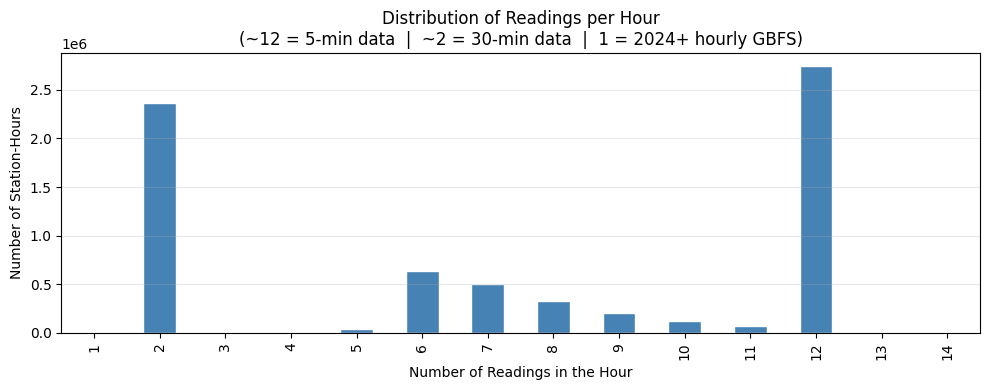


Station-hours with 3 or fewer readings: 2,370,309 (33.7%)
Note: reading_count=2 for 2022-2023 data is expected (30-min Format B files)
Note: reading_count=1 for 2024+ GBFS data is expected (hourly snapshots)


In [14]:
print('Reading count distribution:')
print(df['reading_count'].value_counts().sort_index().head(15))

plt.figure(figsize=(10, 4))
df['reading_count'].value_counts().sort_index().plot(
    kind='bar', color='steelblue', edgecolor='white')
plt.title(
    'Distribution of Readings per Hour\n'
    '(~12 = 5-min data  |  ~2 = 30-min data  |  1 = 2024+ hourly GBFS)',
    fontsize=12)
plt.xlabel('Number of Readings in the Hour')
plt.ylabel('Number of Station-Hours')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

sparse = (df['reading_count'] <= 3).sum()
print(f'\nStation-hours with 3 or fewer readings: {sparse:,} ({sparse/len(df)*100:.1f}%)')
print('Note: reading_count=2 for 2022-2023 data is expected (30-min Format B files)')
print('Note: reading_count=1 for 2024+ GBFS data is expected (hourly snapshots)')